In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split("\\")[-1]
print(case[0])

D:\Promotion\neurolib\GUI\gui\data\00000
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


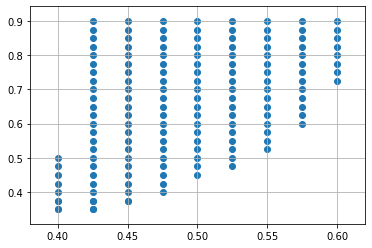

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [83]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [8]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [46]:
i_stepsize = 10
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
-------  40 0.5500000000000003 0.5250000000000002
-------  50 0.5000000000000002 0.5750000000000003
-------  60 0.4250000000000001 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  80 0.5750000000000002 0.6750000000000004
-------  90 0.47500000000000014 0.7250000000000004
-------  100 0.5250000000000001 0.7500000000000004
-------  110 0.5750000000000002 0.7750000000000005
-------  120 0.4250000000000001 0.8250000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  140 0.5250000000000001 0.8750000000000006
-------  150 0.5750000000000002 0.9000000000000006


-------  0 0.4000000000000001 0.3500000000000001
-------  50 0.5000000000000002 0.5750000000000003
-------  100 0.5250000000000001 0.7500000000000004
-------  150 0.5750000000000002 0.9000000000000006
[]


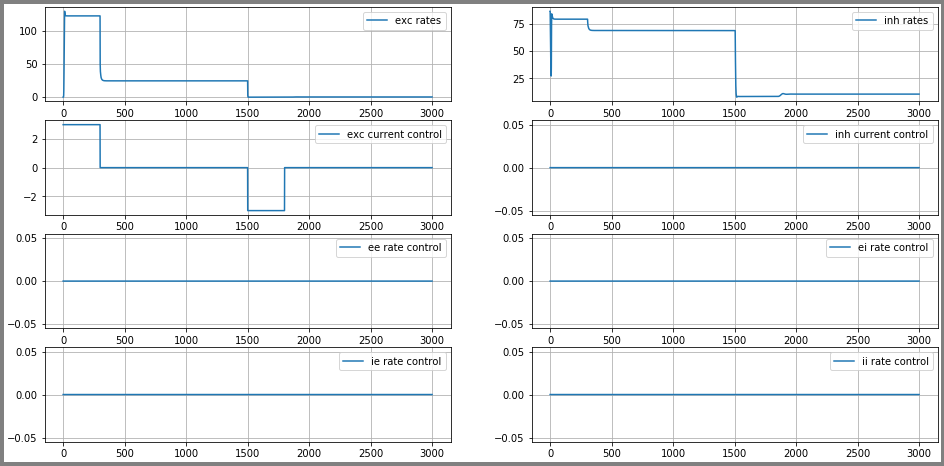

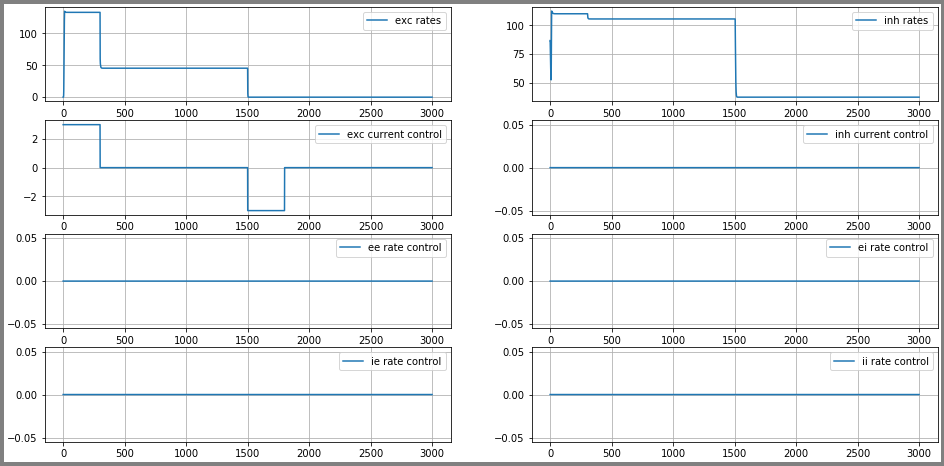

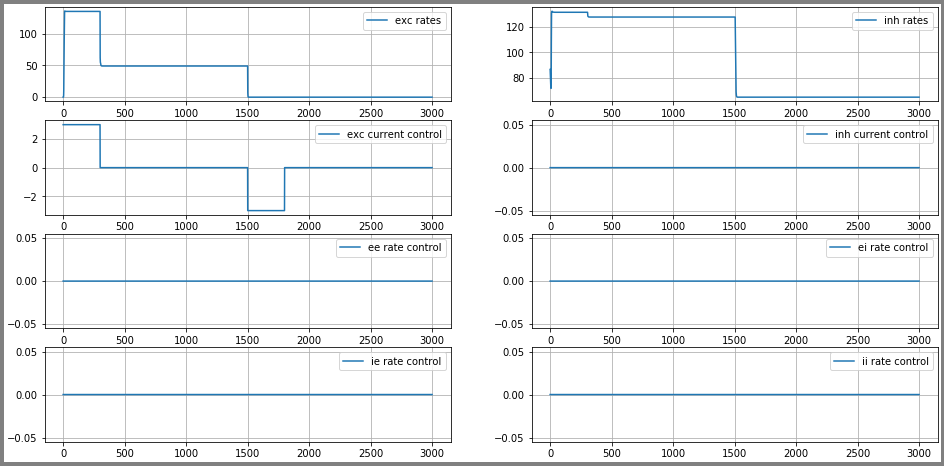

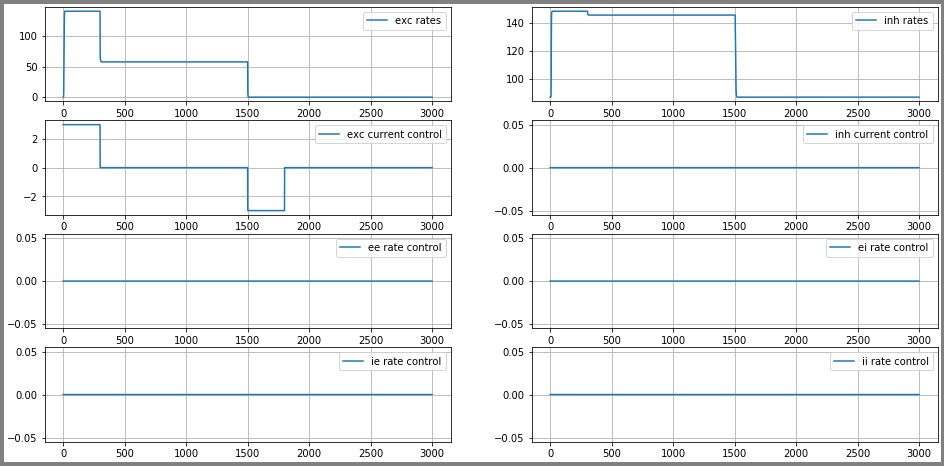

In [26]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

In [48]:
factor_iteration = 10.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.4064792389245
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.4064792389245
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.4064792389245
Gradient descend method:  None
RUN  1 , total integrated cost =  1597.4109736497624
RUN  2 , total integrated cost =  544.6226396133721
RUN  3 , total integrated cost =  381.64393949012253
RUN  4 , total integrated cost =  232.46534562120786
RUN  5 , total integrated cost =  143.00481133447147
RUN  6 , total integrated cost =  50.324193916902146
RUN  7 , total integrated cost =  40.21391216900157
RUN  8 , total integrated cost =  36.11072927299298
RUN  9 , total integrated cost =  33.832417705125536
RUN  10 , total integrated cost =  32.25388693033389
RU

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  14.917913684950468
RUN  1000 , total integrated cost =  14.917913684950468
Improved over  1000  iterations in  20.976041400000213  seconds by  99.74725709356984  percent.
Problem in initial value trasfer:  Vmean_exc -56.62760785616536 -56.627608219159505
weight =  3956.589777827584
set cost params:  1.0 0.0 3956.589777827584
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5896.049393002368
Gradient descend method:  None
RUN  1 , total integrated cost =  5707.742440274435
RUN  2 , total integrated cost =  5703.827010708313
RUN  3 , total integrated cost =  5647.1310762209705
RUN  4 , total integrated cost =  5634.259467930564
RUN  5 , total integrated cost =  5634.177049569563
RUN  6 , total integrated cost =  5634.136736423657
RUN  7 , total integrated cost =  5634.080418816132
RUN  8 , total integrated cost =  5633.796288442228
RUN  9 , total integrated cost =  5600.780467927231
RUN  10 , total integrated cost =  5591.885491

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  26 , total integrated cost =  5591.783034323322
Improved over  26  iterations in  0.594923000000108  seconds by  5.160512376985167  percent.
Problem in initial value trasfer:  Vmean_exc -56.6270814117829 -56.62708071189591
-------  10 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.2898282003225
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.2898282003225
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.2898282003225
Gradient descend method:  None
RUN  1 , total integrated cost =  1584.168404036925
RUN  2 , total integrated cost =  1492.4296382023383
RUN  3 , total integrated cost =  1369.5524896902218
RUN  4 , total integrated cost =  1288.5744463450685
RUN  5 , total integrated cost =  1165.4408132471876
RU

...

Control only changes marginally.
RUN  494 , total integrated cost =  15.67957697130328
Improved over  494  iterations in  13.080591599999934  seconds by  99.95454645551884  percent.
Problem in initial value trasfer:  Vmean_exc -56.70311892974569 -56.703118916082616
weight =  22000.484481785174
set cost params:  1.0 0.0 22000.484481785174
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34487.48266010641
Gradient descend method:  None
RUN  1 , total integrated cost =  33924.032343494495
RUN  2 , total integrated cost =  33923.31815012555
RUN  3 , total integrated cost =  33923.22264951654
RUN  4 , total integrated cost =  33923.18169749445
RUN  5 , total integrated cost =  33923.15624107136
RUN  6 , total integrated cost =  33923.12032937476
RUN  7 , total integrated cost =  33922.94216339415
RUN  8 , total integrated cost =  33920.526954366935
RUN  9 , total integrated cost =  33899.86871547287
RUN  10 , total integrated cost =  33897.49431872623
RUN  11 , total 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  49 , total integrated cost =  33868.25310643614
Improved over  49  iterations in  1.2510234999999739  seconds by  1.7955197245711645  percent.
Problem in initial value trasfer:  Vmean_exc -56.70312047297021 -56.7031203897289
-------  90 0.47500000000000014 0.7250000000000004
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15143.75511030513
Gradient descend method:  None
RUN  0 , total integrated cost =  15143.75511030513
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15143.75511030513
Gradient descend method:  None
RUN  1 , total integrated cost =  15143.75511030513
Control only changes marginally.
RUN  1 , total integrated cost =  15143.75511030513
Improved over  1  iterations in  0.059837899999820365  seconds by  0.0  percent.
weight =  9.999999999999998
set cost params:  1.0

ERROR:root:Problem in initial value trasfer


32769.29808337128
RUN  18 , total integrated cost =  32769.29808337128
Control only changes marginally.
RUN  18 , total integrated cost =  32769.29808337128
Improved over  18  iterations in  0.46519209999996747  seconds by  3.291449690178169  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334404216854 -56.70334402313509
-------  120 0.4250000000000001 0.8250000000000005
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879791508
Gradient descend method:  None
RUN  0 , total integrated cost =  5845.286879791508
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879791508
Gradient descend method:  None
RUN  1 , total integrated cost =  5845.286879791508
Control only changes marginally.
RUN  1 , total integrated cost =  5845.286879791508
Improved over  1  iterations in  0.04847490000020116  seco

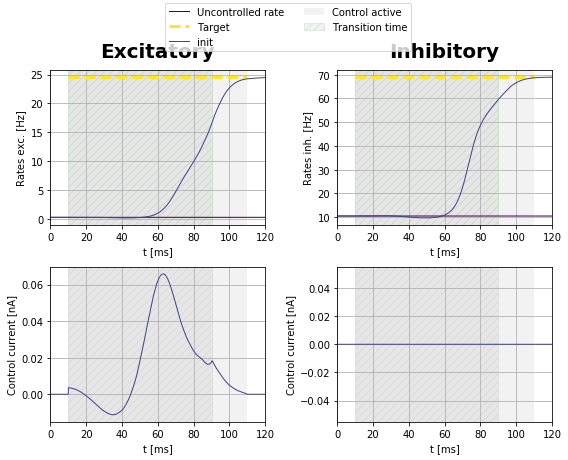

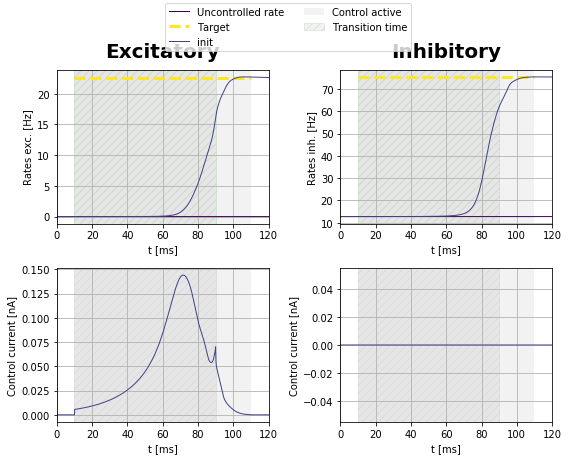

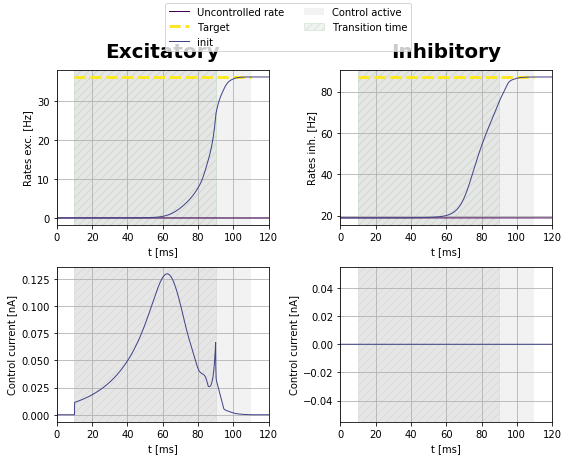

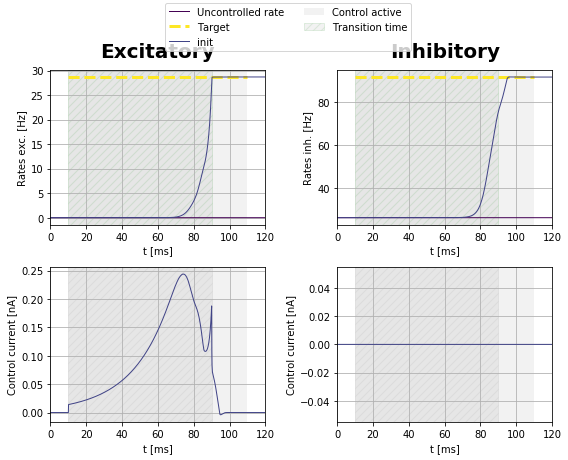

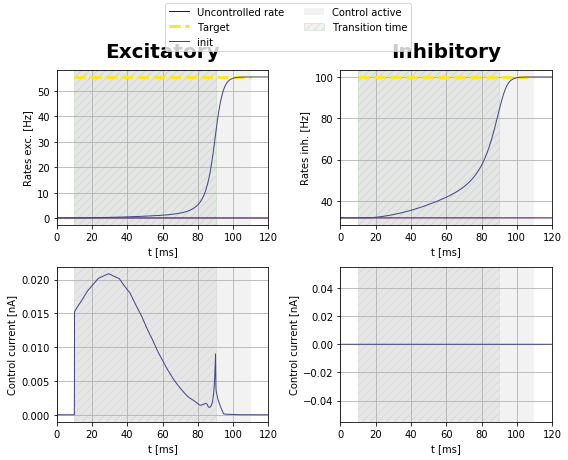

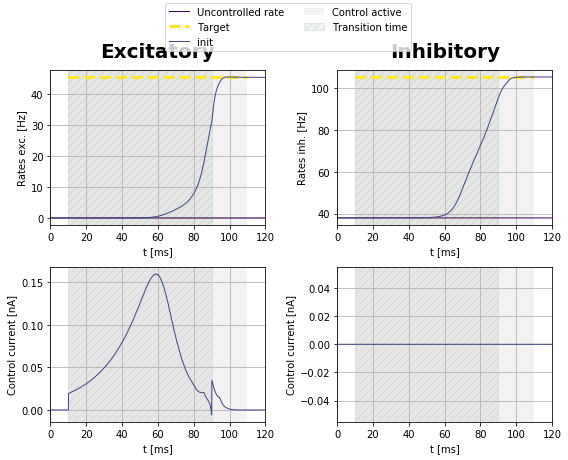

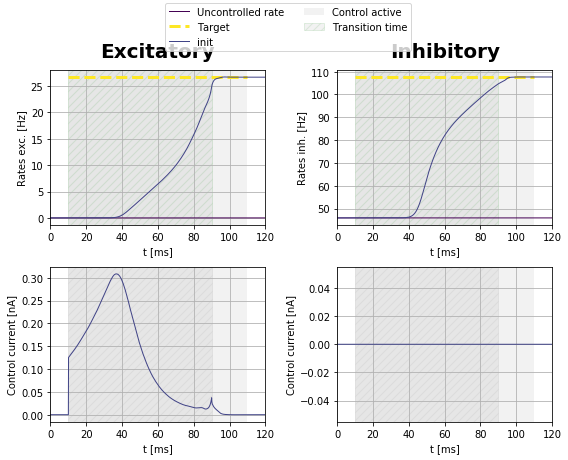

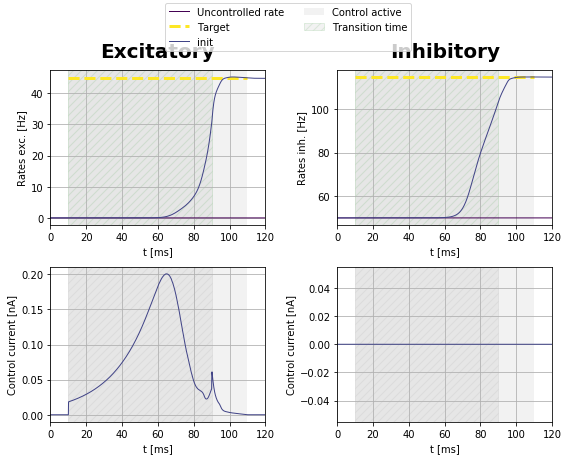

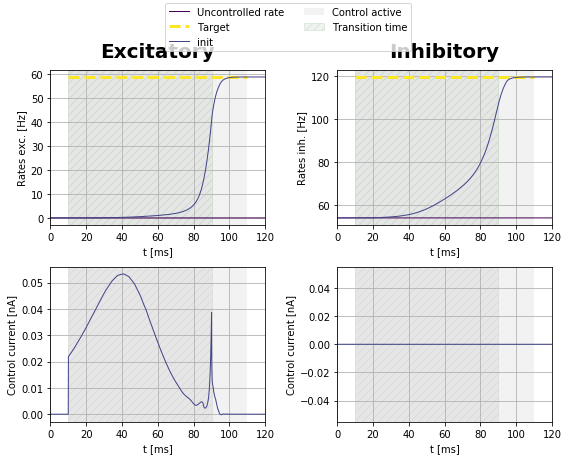

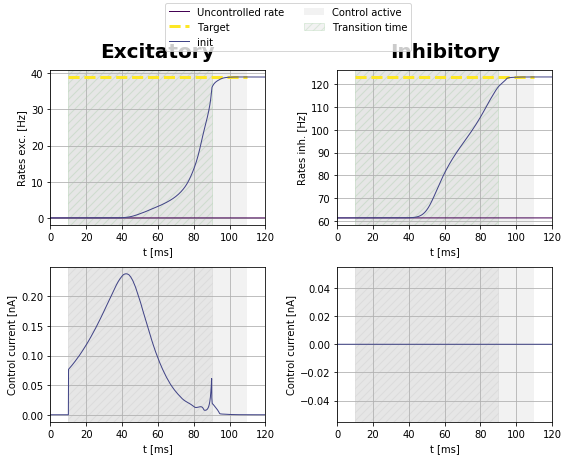

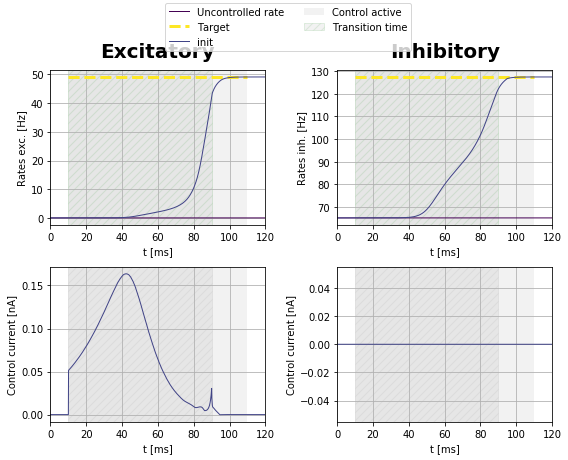

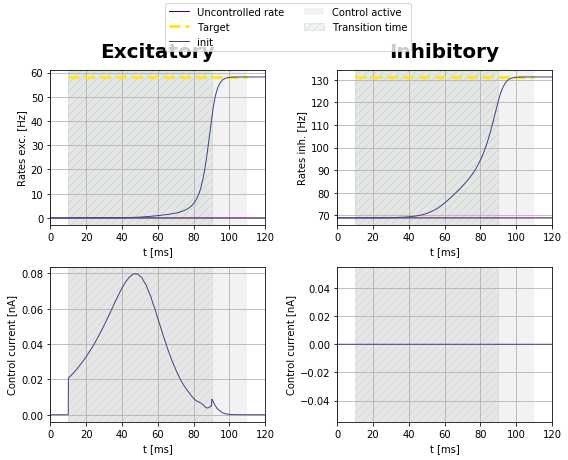

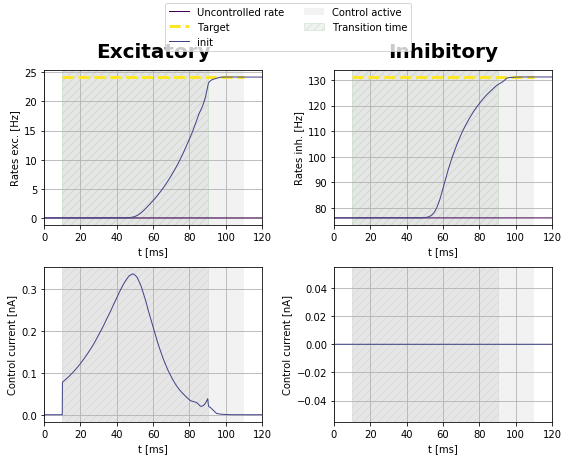

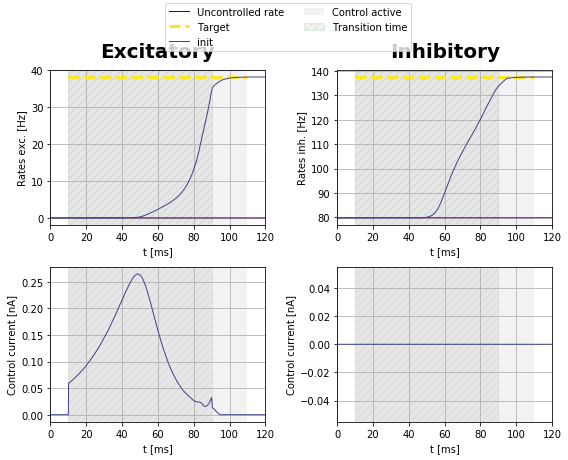

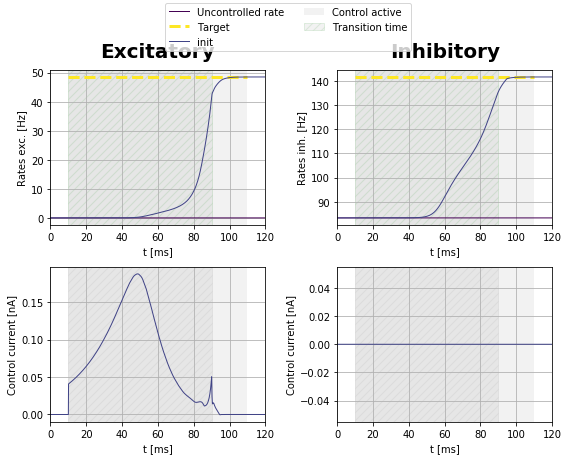

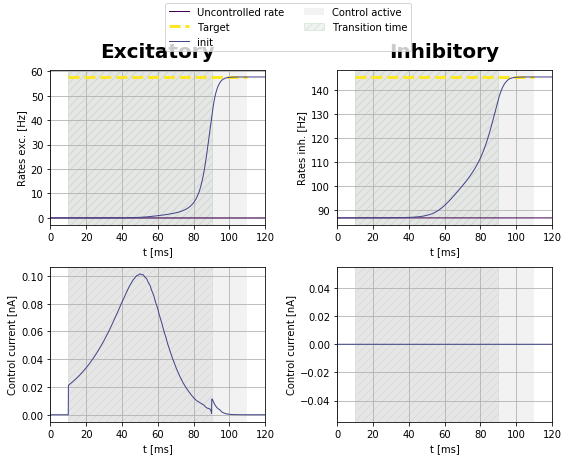

In [73]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [74]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
-------  40 0.5500000000000003 0.5250000000000002
-------  50 0.5000000000000002 0.5750000000000003
-------  60 0.4250000000000001 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  80 0.5750000000000002 0.6750000000000004
-------  90 0.47500000000000014 0.7250000000000004
-------  100 0.5250000000000001 0.7500000000000004
-------  110 0.5750000000000002 0.7750000000000005
-------  120 0.4250000000000001 0.8250000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  140 0.5250000000000001 0.8750000000000006
-------  150 0.5750000000000002 0.9000000000000006


In [77]:
for k in range(10):

    factor_iteration = 10

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  4180.384310061165
set cost params:  1.0 0.0 4180.384310061165
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.99148342295
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.99148340104
RUN  2 , total integrated cost =  5900.991483397079
RUN  3 , total integrated cost =  5900.991483396486
RUN  4 , total integrated cost =  5900.9914833963485
RUN  5 , total integrated cost =  5900.991483396333
RUN  6 , total integrated cost =  5900.99148339633


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  5900.9914833963285
RUN  8 , total integrated cost =  5900.991483396324
RUN  9 , total integrated cost =  5900.991483396321
RUN  10 , total integrated cost =  5900.991483396318
RUN  11 , total integrated cost =  5900.991483396317
RUN  12 , total integrated cost =  5900.991483396316
State only changes marginally.
RUN  13 , total integrated cost =  5900.991483396316
Control only changes marginally.
RUN  13 , total integrated cost =  5900.991483396316
Improved over  13  iterations in  0.3701117999999042  seconds by  4.5136516746424604e-10  percent.
Problem in initial value trasfer:  Vmean_exc -56.6270142596309 -56.627012752126525
-------  10 0.4000000000000001 0.40000000000000013
weight =  1557.7561961876572
set cost params:  1.0 0.0 1557.7561961876572
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5094.019677846749
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.019677846729
RUN  2 , total integrated cost =  5094.019677846726
RUN  3 , total integrated cost =  5094.019677846726
Control only changes marginally.
RUN  3 , total integrated cost =  5094.019677846726
Improved over  3  iterations in  0.16284709999945335  seconds by  4.405364961712621e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.624522789721645 -56.62452068676818
-------  20 0.4500000000000001 0.4500000000000002
weight =  4094.5838740643826
set cost params:  1.0 0.0 4094.5838740643826
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13014.895415979136
Gradient descend method:  None
RUN  1 , total integrated cost =  13014.895415978592


...

RUN  1 , total integrated cost =  7105.37972683717
Control only changes marginally.
RUN  1 , total integrated cost =  7105.37972683717
Improved over  1  iterations in  0.06851920000008249  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.63158755252247 -56.63158767674966
-------  70 0.5000000000000002 0.6500000000000004
weight =  4232.729815446496
set cost params:  1.0 0.0 4232.729815446496
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20066.37434937812
Gradient descend method:  None
RUN  1 , total integrated cost =  20066.37434937812
Control only changes marginally.
RUN  1 , total integrated cost =  20066.37434937812
Improved over  1  iterations in  0.06964249999964522  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.695438624026586 -56.69542550186197
-------  80 0.5750000000000002 0.6750000000000004
weight =  22409.68954357923
set cost params:  1.0 0.0 22409.68954357923
interpolate adjoint :  True True Tru

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  15137.601772233873
Control only changes marginally.
RUN  1 , total integrated cost =  15137.601772233873
Improved over  1  iterations in  0.07578479999938281  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.679989554076734 -56.67998817876319
-------  100 0.5250000000000001 0.7500000000000004
weight =  5751.496647997499
set cost params:  1.0 0.0 5751.496647997499
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24124.248072960818
Gradient descend method:  None
RUN  1 , total integrated cost =  24124.248072960818
Control only changes marginally.
RUN  1 , total integrated cost =  24124.248072960818
Improved over  1  iterations in  0.06843280000066443  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.701405440848774 -56.70140552891984
-------  110 0.5750000000000002 0.7750000000000005
weight =  15475.204564002945
set cost params:  1.0 0.0 15475.204564002945
interpolate adjoint :  T

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5836.678533704663
Control only changes marginally.
RUN  1 , total integrated cost =  5836.678533704663
Improved over  1  iterations in  0.06880500000079337  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62419309050402 -56.62419331840028
-------  130 0.47500000000000014 0.8500000000000005
weight =  2184.0738527890708
set cost params:  1.0 0.0 2184.0738527890708
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.321154417366
Gradient descend method:  None
RUN  1 , total integrated cost =  14541.321154417366
Control only changes marginally.
RUN  1 , total integrated cost =  14541.321154417366
Improved over  1  iterations in  0.06900360000054206  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67720748215407 -56.67720956809899
-------  140 0.5250000000000001 0.8750000000000006
weight =  5025.727217136738
set cost params:  1.0 0.0 5025.727217136738
interpolate adjoint :  True

In [78]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [40]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [79]:
factor_iteration = 10
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  144.73792325763574
Gradient descend method:  None
RUN  1 , total integrated cost =  25.975689842334674
RUN  2 , total integrated cost =  22.020356200181514
RUN  3 , total integrated cost =  19.236214845805875
RUN  4 , total integrated cost =  18.40502872774661
RUN  5 , total integrated cost =  17.565410555677037
RUN  6 , total integrated cost =  17.119173266648378
RUN  7 , total integrated cost =  16.60173575898318
RUN  8 , total integrated cost =  16.28777529396223
RUN  9 , total integrated cost =  15.714758529185238
RUN  10 , total integrated cost =  15.440903225456935
RUN  11 , total integrated cost =  14.905680028301205
RUN  12 , total integrated cost =  14.836102399582586
RUN  13 , total integrated cost =  14.817795007517958
RUN  14 , total integrated cost =  14.800788700043407
RUN  15 , total integrated cost =  14.792569565322614


ERROR:root:Problem in initial value trasfer


RUN  500 , total integrated cost =  14.1462609021014
RUN  500 , total integrated cost =  14.1462609021014
Improved over  500  iterations in  23.33520580000004  seconds by  90.22629274780954  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761639885931 -56.627616430584105
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  141.31463325621044
Gradient descend method:  HS
RUN  1 , total integrated cost =  141.1143788607722
RUN  2 , total integrated cost =  140.80943047333852
RUN  3 , total integrated cost =  140.7956276765987
RUN  4 , total integrated cost =  140.71284878763282
RUN  5 , total integrated cost =  140.70536967899807
RUN  6 , total integrated cost =  140.65848125020736
RUN  7 , total integrated cost =  140.64962968002527
RUN  8 , total integrated cost =  140.61939808119268
RUN  9 , total integrated cost =  140.475725405287
RUN  10 , total integrated cost =  140.47572540528697
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  116 , total integrated cost =  131.6428460157692
Improved over  116  iterations in  7.8670781999999235  seconds by  6.844151251417685  percent.
Problem in initial value trasfer:  Vmean_exc -56.62770263499858 -56.62770040475604
weight =  4482.651529785287
set cost params:  1.0 0.0 4482.651529785287
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5891.282574278082
Gradient descend method:  None
RUN  1 , total integrated cost =  5771.162002171037
RUN  2 , total integrated cost =  5739.167887822072
RUN  3 , total integrated cost =  5703.361762471017
RUN  4 , total integrated cost =  5424.825110346189
RUN  5 , total integrated cost =  5414.652818819351
RUN  6 , total integrated cost =  5315.950246480795
RUN  7 , total integrated cost =  5277.200767717764
RUN  8 , total integrated cost =  5223.343497358779
RUN  9 , total integrated cost =  5202.202902249213
RUN  10 , total integrated cost =  5175.490437250103
RUN  11 , total integ

...

RUN  5 , total integrated cost =  23475.76209206406
Control only changes marginally.
RUN  5 , total integrated cost =  23475.76209206406
Improved over  5  iterations in  0.6666040000000066  seconds by  0.19434073843362398  percent.
Problem in initial value trasfer:  Vmean_exc -56.70066959294947 -56.70066969715167
-------  150 0.5750000000000002 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  206.77280824977052
Gradient descend method:  None
RUN  1 , total integrated cost =  28.329710137031046
RUN  2 , total integrated cost =  27.86715380187899
RUN  3 , total integrated cost =  27.64969570500754
RUN  4 , total integrated cost =  27.549729039717175
RUN  5 , total integrated cost =  27.47304017909678
RUN  6 , total integrated cost =  27.43614298899423
RUN  7 , total integrated cost =  27.395836876542663
RUN  8 , total integrated cost =  27.37436712857978
RUN  9 , total integrated cost =  27.331115887313217
RUN  10 ,

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  267.8522374499654
RUN  16 , total integrated cost =  267.8522374499654
Control only changes marginally.
RUN  16 , total integrated cost =  267.8522374499654
Improved over  16  iterations in  1.8424323999997796  seconds by  0.5128875821725671  percent.
Problem in initial value trasfer:  Vmean_exc -56.703541256037006 -56.703541290566555
weight =  12427.51349079967
set cost params:  1.0 0.0 12427.51349079967
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33267.265329965245
Gradient descend method:  None
RUN  1 , total integrated cost =  33028.820028081565
RUN  2 , total integrated cost =  33028.46014050886
RUN  3 , total integrated cost =  33028.446936395456
RUN  4 , total integrated cost =  33028.44661939393
RUN  5 , total integrated cost =  33028.44661177862
RUN  6 , total integrated cost =  33028.44661177859


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  33028.44661177859
Control only changes marginally.
RUN  7 , total integrated cost =  33028.44661177859
Improved over  7  iterations in  0.8695002999993449  seconds by  0.7178790195644211  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354239873271 -56.70354238243452


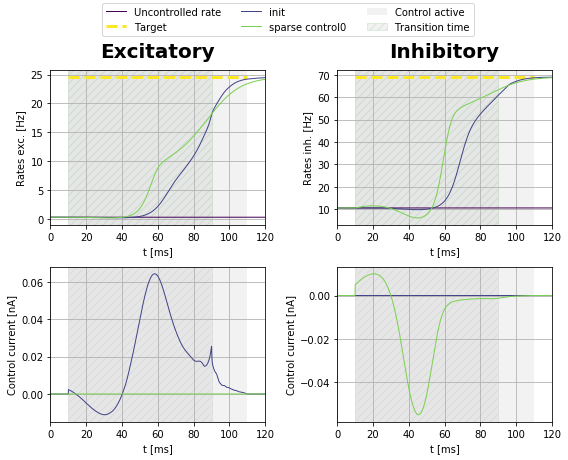

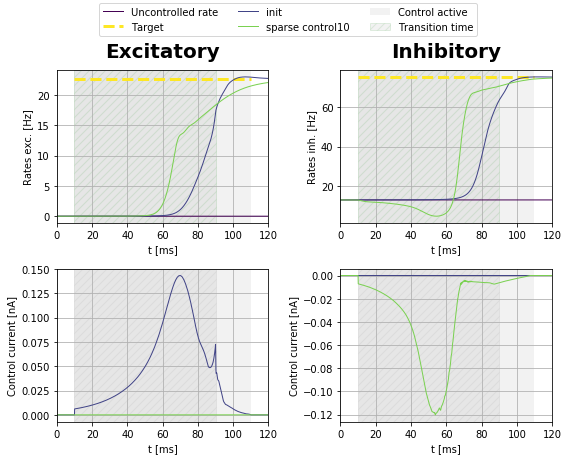

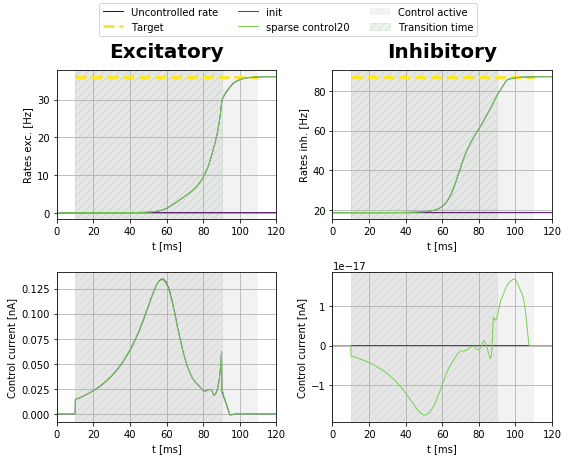

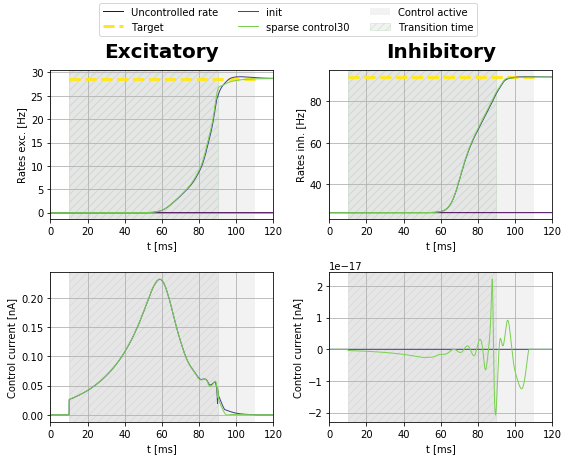

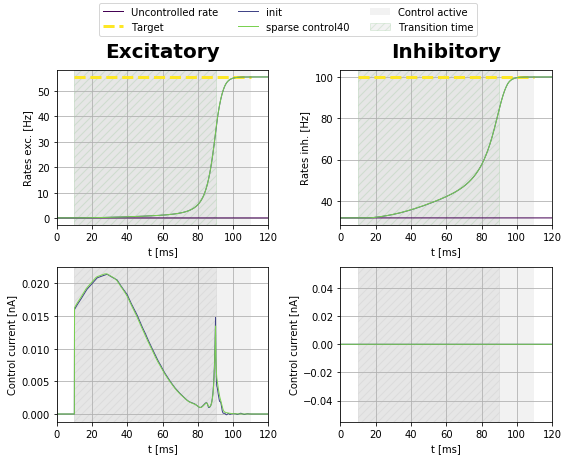

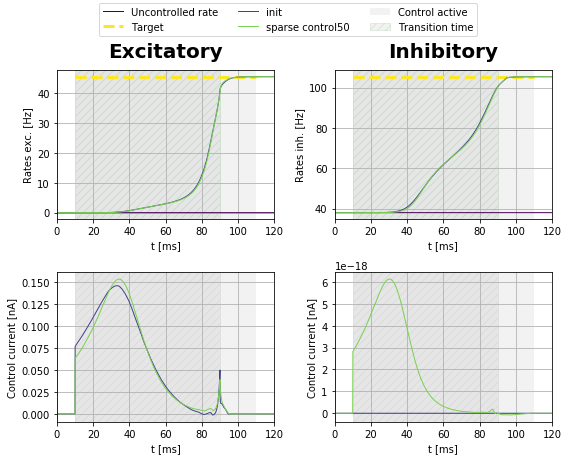

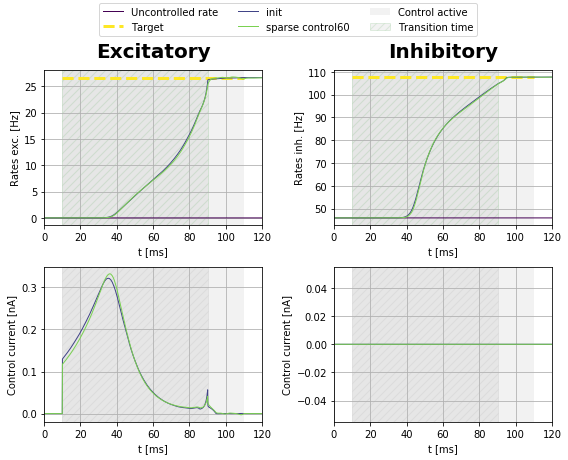

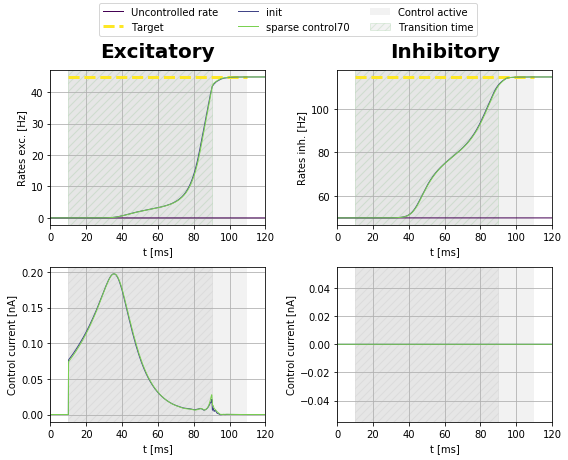

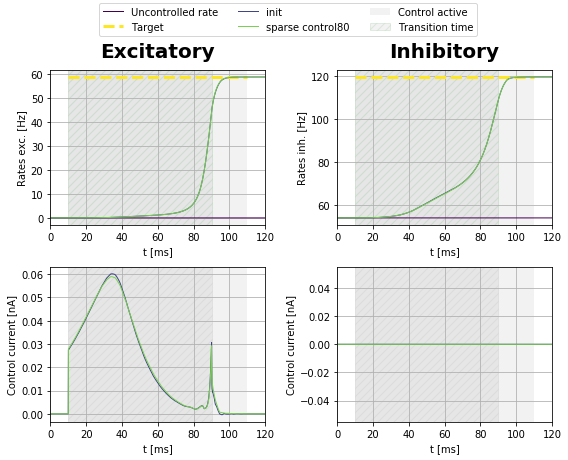

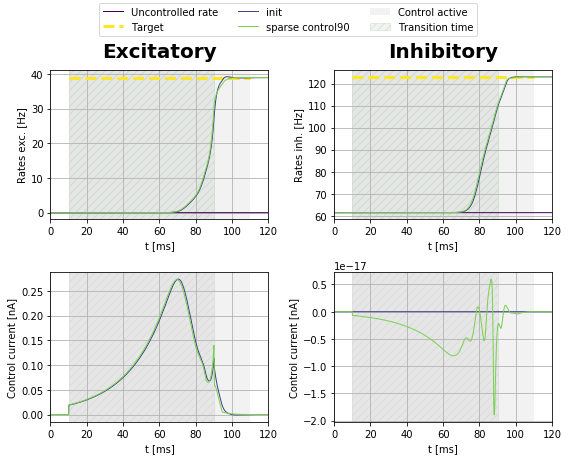

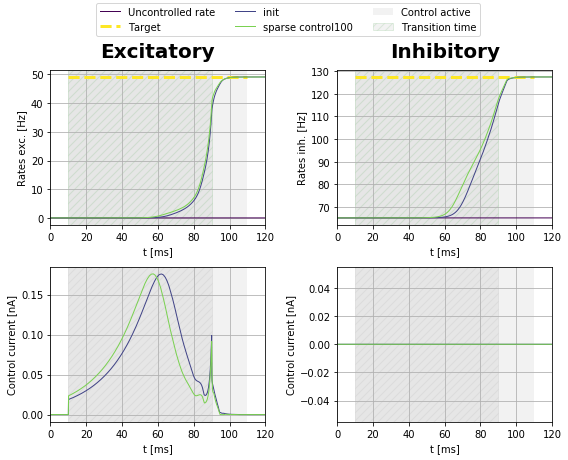

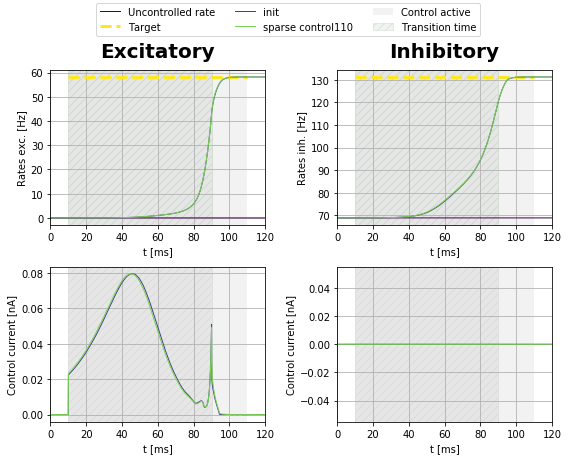

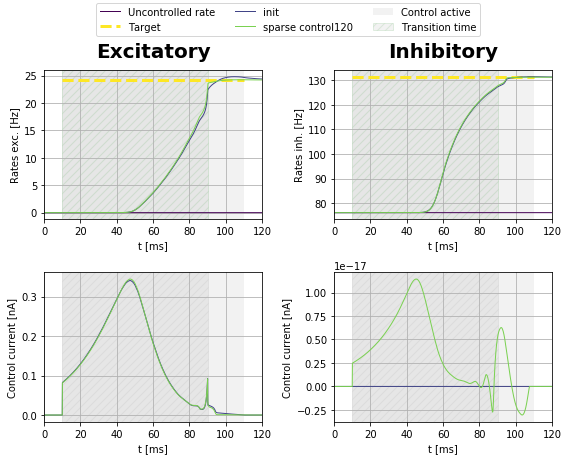

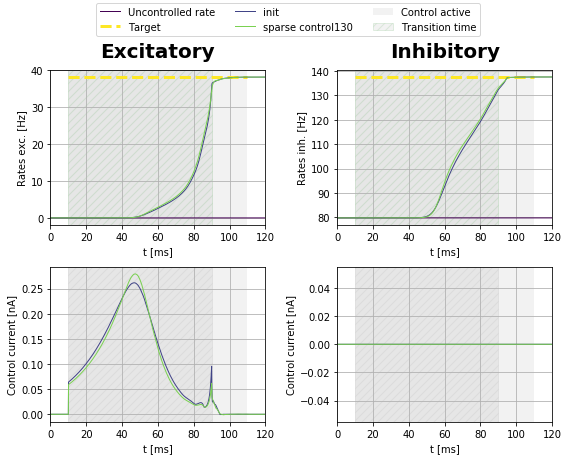

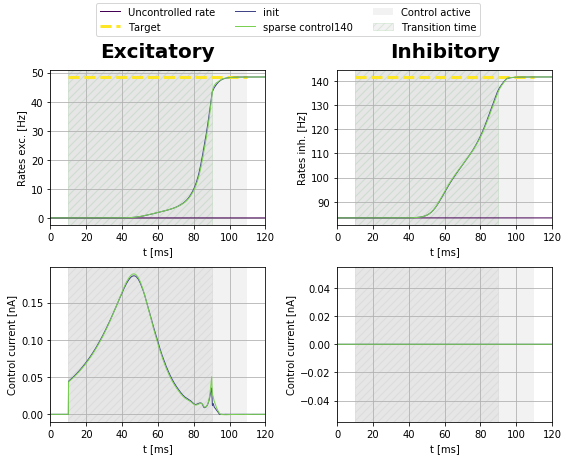

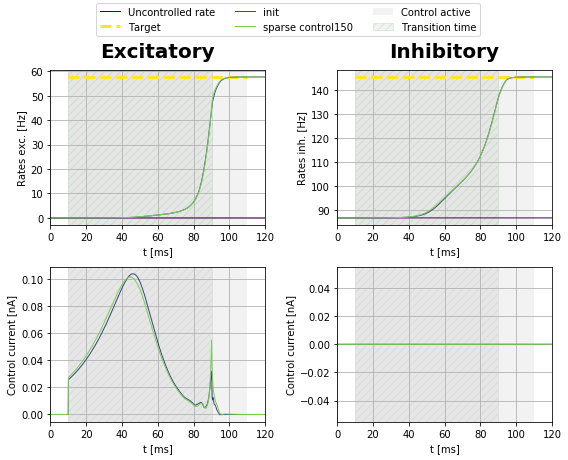

In [49]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [81]:
factor_iteration = 10

for k in range(10):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5757.802444384291
set cost params:  1.0 0.0 5757.802444384291
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.567867798826
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5900.567867798826
Control only changes marginally.
RUN  1 , total integrated cost =  5900.567867798826
Improved over  1  iterations in  0.20081719999961933  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62602904694113 -56.62604166770659
-------  10 0.4000000000000001 0.40000000000000013
weight =  2096.6605521206234
set cost params:  1.0 0.0 2096.6605521206234
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5094.591741515315
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.591741515315
Control only changes marginally.
RUN  1 , total integrated cost =  5094.591741515315
Improved over  1  iterations in  0.21745730000020558  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62577228328011 -56.625751314339745
-------  20 0.4500000000000001 0.4500000000000002
weight =  4185.426266774327
set cost params:  1.0 0.0 4185.426266774327
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13014.96130322521
Gradient descend method:  None


...

RUN  1 , total integrated cost =  14541.333387886809
Control only changes marginally.
RUN  1 , total integrated cost =  14541.333387886809
Improved over  1  iterations in  0.21659060000001773  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677293644397174 -56.67729252946659
-------  140 0.5250000000000001 0.8750000000000006
weight =  5027.0370679452835
set cost params:  1.0 0.0 5027.0370679452835
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23527.955860148293
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23527.955860148293
Control only changes marginally.
RUN  1 , total integrated cost =  23527.955860148293
Improved over  1  iterations in  0.21019720000003872  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700669587961016 -56.70066969233649
-------  150 0.5750000000000002 0.9000000000000006
weight =  12525.294574782874
set cost params:  1.0 0.0 12525.294574782874
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33287.39385322604
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.39385322604
Control only changes marginally.
RUN  1 , total integrated cost =  33287.39385322604
Improved over  1  iterations in  0.21687699999984034  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703542401859615 -56.70354238542314


In [85]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)